<h1 style="text-align: center;font-size: 40px;">Cataract Prediction using A2C</h1>

---

<h3>Dataset Information:</h3>
Ocular Disease Intelligent Recognition (ODIR) is a structured ophthalmic database of 5,000 patients with age, color fundus photographs from left and right eyes and doctors' diagnostic keywords.
We classify images into two categories:
<ul>
  <li><b>Normal</b> – healthy fundus images</li>
  <li><b>Cataract</b> – images diagnosed with cataract</li>
</ul>

In [17]:
# Step 1: Download dataset using KaggleHub
import kagglehub
path = kagglehub.dataset_download('andrewmvd/ocular-disease-recognition-odir5k')
print('Path to dataset files:', path)

Path to dataset files: /kaggle/input/datasets/andrewmvd/ocular-disease-recognition-odir5k


In [18]:
# Step 2: Install required libraries
!pip install tensorflow scikit-learn scipy

In [19]:
# Step 3: Import necessary libraries
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Input, Dense, Dropout


In [20]:
# Step 4: Define dataset paths
csv_path  = os.path.join(path, 'full_df.csv')
image_dir = os.path.join(path, 'preprocessed_images')
df = pd.read_csv(csv_path)
df.head(3)

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,Left-Diagnostic Keywords,Right-Diagnostic Keywords,N,D,G,C,A,H,M,O,filepath,labels,target,filename
0,0,69,Female,0_left.jpg,0_right.jpg,cataract,normal fundus,0,0,0,1,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",0_right.jpg
1,1,57,Male,1_left.jpg,1_right.jpg,normal fundus,normal fundus,1,0,0,0,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",1_right.jpg
2,2,42,Male,2_left.jpg,2_right.jpg,laser spot，moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,1,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",2_right.jpg


In [21]:
# Step 5: Extract Cataract & Normal image paths
def has_cataract(text):
    return 1 if 'cataract' in str(text).lower() else 0

df['left_cataract']  = df['Left-Diagnostic Keywords'].apply(has_cataract)
df['right_cataract'] = df['Right-Diagnostic Keywords'].apply(has_cataract)

left_cataract   = df.loc[(df.C == 1) & (df.left_cataract  == 1)]['Left-Fundus'].values
right_cataract  = df.loc[(df.C == 1) & (df.right_cataract == 1)]['Right-Fundus'].values
cataract_images = np.concatenate((left_cataract, right_cataract), axis=0)

left_normal   = df.loc[(df.C == 0) & (df['Left-Diagnostic Keywords']  == 'normal fundus')]['Left-Fundus'].sample(250, random_state=42).values
right_normal  = df.loc[(df.C == 0) & (df['Right-Diagnostic Keywords'] == 'normal fundus')]['Right-Fundus'].sample(250, random_state=42).values
normal_images = np.concatenate((left_normal, right_normal), axis=0)

print(f'Cataract images : {len(cataract_images)}')
print(f'Normal images   : {len(normal_images)}')

Cataract images : 594
Normal images   : 500


In [22]:
# Step 6: Build DataFrame
image_paths = (
    [os.path.join(image_dir, img) for img in cataract_images] +
    [os.path.join(image_dir, img) for img in normal_images]
)
labels = ['CATARACT'] * len(cataract_images) + ['NORMAL'] * len(normal_images)

data_df = pd.DataFrame({'filename': image_paths, 'class': labels})
data_df['label'] = data_df['class'].map({'NORMAL': 0.0, 'CATARACT': 1.0})

print(data_df['class'].value_counts())

# Validate image paths — drop rows where file doesn't exist
data_df = data_df[data_df['filename'].apply(os.path.exists)].reset_index(drop=True)
print(f'Valid images after path check: {len(data_df)}')
data_df.head()

class
CATARACT    594
NORMAL      500
Name: count, dtype: int64
Valid images after path check: 1088


,filename,class,label
0,/kaggle/input/datasets/andrewmvd/ocular-diseas...,CATARACT,1.0
1,/kaggle/input/datasets/andrewmvd/ocular-diseas...,CATARACT,1.0
2,/kaggle/input/datasets/andrewmvd/ocular-diseas...,CATARACT,1.0
3,/kaggle/input/datasets/andrewmvd/ocular-diseas...,CATARACT,1.0
4,/kaggle/input/datasets/andrewmvd/ocular-diseas...,CATARACT,1.0


<h3>Sample Images from Dataset</h3>

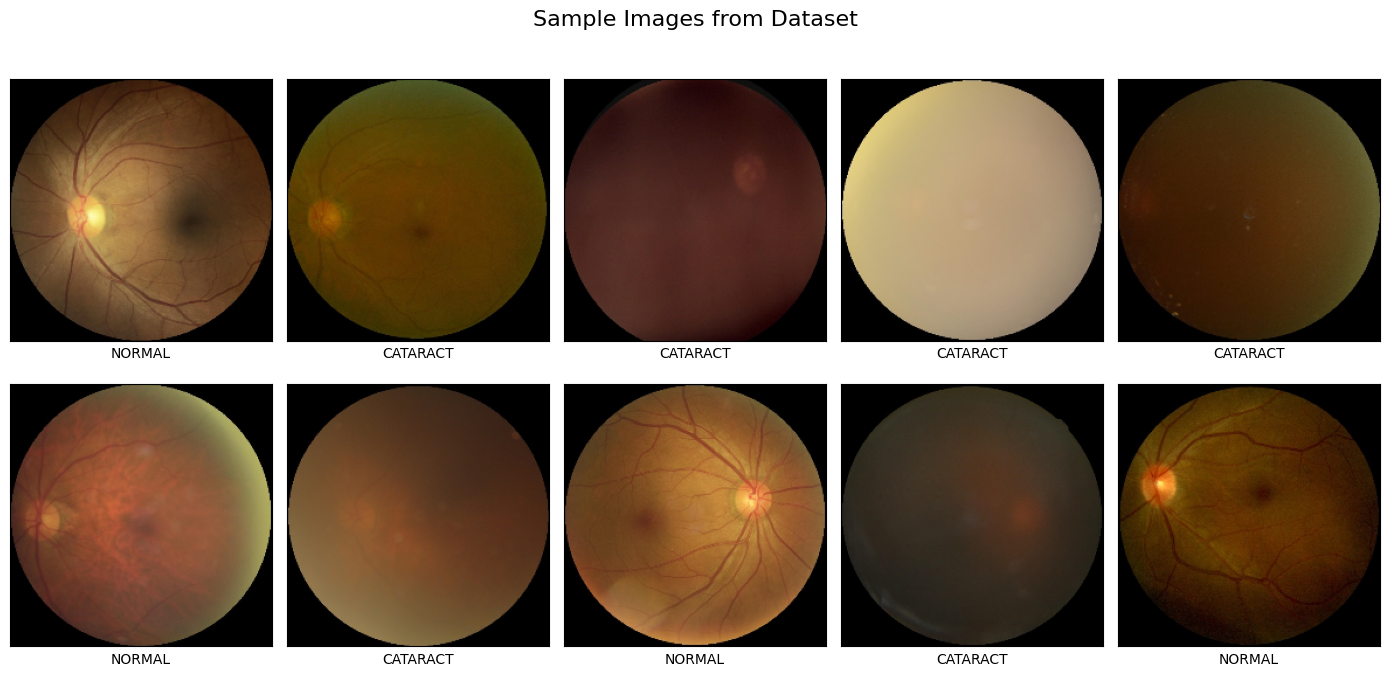

In [23]:
# Step 7: Visualise sample images from dataset
plt.figure(figsize=(14, 7))
sample_rows = data_df.sample(10, random_state=1).reset_index(drop=True)
for i, row in sample_rows.iterrows():
    image = cv2.imread(row['filename'])
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (224, 224))
    plt.subplot(2, 5, i + 1)
    plt.imshow(image)
    plt.xlabel(row['class'])
    plt.xticks([]); plt.yticks([])
plt.suptitle('Sample Images from Dataset', fontsize=16)
plt.tight_layout()
plt.show()

In [24]:
# Step 8: Train / Validation split
train_df, val_df = train_test_split(
    data_df, test_size=0.2, stratify=data_df['label'], random_state=42
)
print(f'Train size: {len(train_df)} | Val size: {len(val_df)}')

Train size: 870 | Val size: 218


In [25]:
# Step 9: Image loader + Pre-extract features ONCE (avoids repeated CNN calls)
IMAGE_SIZE = (224, 224)

def load_image(path):
    img = cv2.imread(path)
    if img is None:
        for ext in ['.jpg', '.jpeg', '.png', '.bmp']:
            alt = os.path.splitext(path)[0] + ext
            img = cv2.imread(alt)
            if img is not None:
                break
    if img is None:
        img = np.zeros((IMAGE_SIZE[0], IMAGE_SIZE[1], 3), dtype=np.uint8)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMAGE_SIZE)
    return tf.keras.applications.mobilenet_v2.preprocess_input(img.astype('float32'))

# Build feature extractor (MobileNetV2 backbone — downloaded only once)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model as KerasModel

base_fe = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
feat_extractor = KerasModel(inputs=base_fe.input,
                            outputs=GlobalAveragePooling2D()(base_fe.output))

BATCH = 64
def extract_features(paths):
    feats = []
    for i in range(0, len(paths), BATCH):
        batch = np.array([load_image(p) for p in paths[i:i+BATCH]])
        feats.append(feat_extractor.predict(batch, verbose=0))
    return np.vstack(feats)

train_paths_arr  = train_df['filename'].values
train_labels_arr = train_df['label'].values.astype(int)
val_paths_arr    = val_df['filename'].values
val_labels_arr   = val_df['label'].values.astype(int)

print('Pre-extracting train features...')
train_features = extract_features(train_paths_arr)
print('Pre-extracting val features...')
val_features   = extract_features(val_paths_arr)
print(f'Train: {train_features.shape} | Val: {val_features.shape}')

Pre-extracting train features...
Pre-extracting val features...
Train: (870, 1280) | Val: (218, 1280)


In [36]:
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.regularizers import l2

FEAT_DIM = train_features.shape[1] # This is 1280

def build_actor_critic():
    inp = Input(shape=(FEAT_DIM,))
    
    # Shared layers
    shared = Dense(128, activation='relu', kernel_regularizer=l2(1e-3))(inp)
    shared = Dropout(0.4)(shared)
    shared = Dense(64, activation='relu', kernel_regularizer=l2(1e-3))(shared)
    shared = Dropout(0.3)(shared)
    
    # Actor head (Actions: Normal vs Cataract)
    actor = Dense(2, activation='softmax', name='actor')(shared)
    
    # Critic head (State value)
    critic = Dense(1, activation='linear', name='critic')(shared)
    
    return Model(inputs=inp, outputs=[actor, critic])

# Re-build and summarize
ac_model = build_actor_critic()
optimizer = Adam(learning_rate=1e-4)
ac_model.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 1280)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 128)       │    163,968 │ input_layer_11[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 128)       │          0 │ dense_17[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 64)        │      8,256 │ dropout_16[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_17          │ (None, 64)        │          0 │ dense_18[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ actor (Dense)       │ (None, 2)         │        130 │ dropout_17[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ critic (Dense)      │ (None, 1)         │         65 │ dropout_17[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 172,419 (673.51 KB)

 Trainable params: 172,419 (673.51 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
# Step 11: A2C Hyperparameters
GAMMA    = 0.99
EPISODES = 10
ENTROPY_BETA = 0.01     # encourage exploration via entropy bonus

In [41]:
# Step 12: Train the A2C agent
train_paths   = train_df['filename'].values
train_labels  = train_df['label'].values
val_paths_arr  = val_df['filename'].values
val_labels_arr = val_df['label'].values

train_acc_history, val_acc_history   = [], []
train_loss_history, val_loss_history = [], []

for episode in range(EPISODES):
    idx_order  = np.random.permutation(len(train_paths))
    ep_correct, ep_losses = 0, []

    for idx in idx_order:
        state = train_features[idx:idx+1].astype(np.float32)
        label = int(train_labels_arr[idx])

        with tf.GradientTape() as tape:
            action_probs, value = ac_model(state, training=True)
            action_probs = action_probs[0]
            value        = value[0, 0]

            action  = int(tf.random.categorical(tf.math.log([action_probs]), 1)[0, 0])
            reward  = 1.0 if action == label else -1.0

            # Advantage = reward - value  (single-step, no next state needed)
            advantage = reward - value

            log_prob        = tf.math.log(action_probs[action] + 1e-8)
            actor_loss      = -log_prob * tf.stop_gradient(advantage)
            critic_loss     = tf.square(advantage)
            entropy         = -tf.reduce_sum(action_probs * tf.math.log(action_probs + 1e-8))
            total_loss      = actor_loss + 0.5 * critic_loss - ENTROPY_BETA * entropy

        grads = tape.gradient(total_loss, ac_model.trainable_variables)
        optimizer.apply_gradients(zip(grads, ac_model.trainable_variables))

        ep_correct += int(action == label)
        ep_losses.append(float(total_loss))

    tr_acc  = ep_correct / len(train_paths)
    tr_loss = float(np.mean(ep_losses))

    # Validation pass
    # Batch validation on pre-extracted features — fast!
    probs_all, _ = ac_model.predict(val_features, verbose=0)
    val_preds    = np.argmax(probs_all, axis=1)
    val_acc   = float(np.mean(val_preds == val_labels_arr))
    val_loss  = float(np.mean((val_preds - val_labels_arr) ** 2))

    train_acc_history.append(tr_acc)
    val_acc_history.append(val_acc)
    train_loss_history.append(tr_loss)
    val_loss_history.append(val_loss)

    print(f'Episode {episode+1}/{EPISODES} | '
          f'Train Acc: {tr_acc:.4f} | Val Acc: {val_acc:.4f} | Loss: {tr_loss:.4f}')

Episode 1/10 | Train Acc: 0.7287 | Val Acc: 0.9358 | Loss: 0.4102
Episode 2/10 | Train Acc: 0.8724 | Val Acc: 0.9266 | Loss: 0.1577
Episode 3/10 | Train Acc: 0.8897 | Val Acc: 0.9220 | Loss: 0.1249
Episode 4/10 | Train Acc: 0.9080 | Val Acc: 0.9312 | Loss: 0.1450
Episode 5/10 | Train Acc: 0.9138 | Val Acc: 0.9358 | Loss: 0.1254
Episode 6/10 | Train Acc: 0.9218 | Val Acc: 0.9312 | Loss: 0.0900
Episode 7/10 | Train Acc: 0.9161 | Val Acc: 0.9358 | Loss: 0.1115
Episode 8/10 | Train Acc: 0.9161 | Val Acc: 0.9495 | Loss: 0.0785
Episode 9/10 | Train Acc: 0.9368 | Val Acc: 0.9495 | Loss: 0.0782
Episode 10/10 | Train Acc: 0.9379 | Val Acc: 0.9358 | Loss: 0.0766


In [42]:
# Step 13: Generate final predictions on validation set
probs_val, _ = ac_model.predict(val_features, verbose=0)
y_pred_prob  = probs_val[:, 1]   # probability of CATARACT

y_pred_prob = np.array(y_pred_prob)
y_pred      = (y_pred_prob > 0.5).astype(int)
y_true      = val_labels_arr.astype(int)

<h3>Learning Curve</h3>

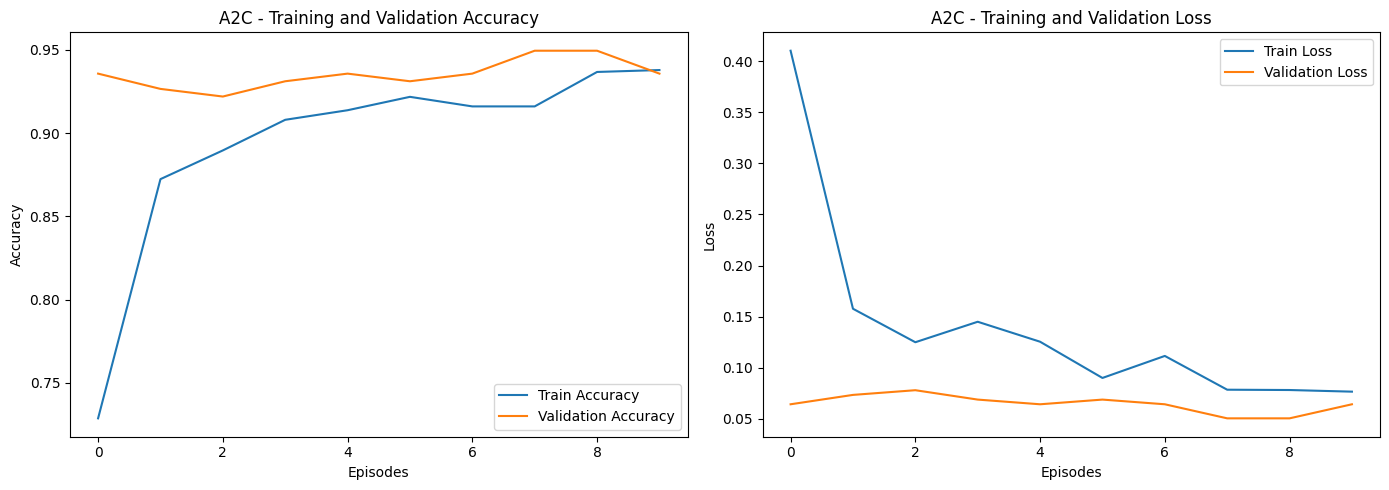

In [43]:
# Plot training history (combined)
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(train_acc_history,  label='Train Accuracy')
plt.plot(val_acc_history,    label='Validation Accuracy')
plt.title('A2C - Training and Validation Accuracy')
plt.xlabel('Episodes')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_loss_history, label='Train Loss')
plt.plot(val_loss_history,   label='Validation Loss')
plt.title('A2C - Training and Validation Loss')
plt.xlabel('Episodes')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

### Separate Accuracy & Loss Curves

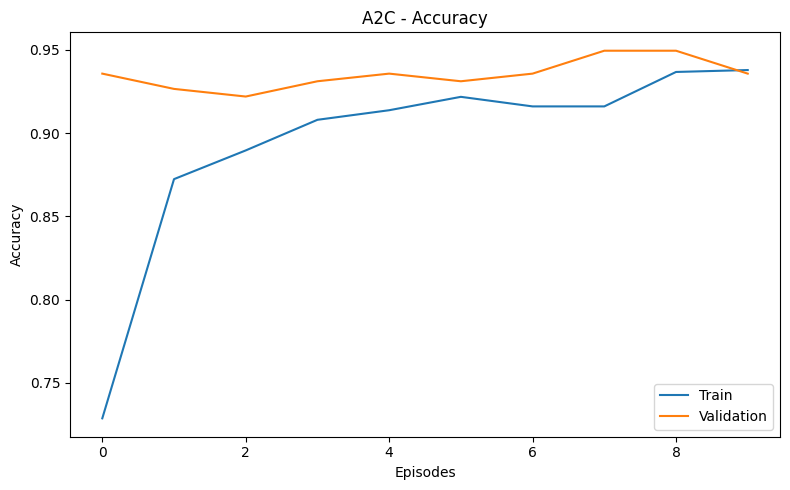

In [44]:
# Accuracy Curve
plt.figure(figsize=(8, 5))
plt.plot(train_acc_history,  label='Train')
plt.plot(val_acc_history,    label='Validation')
plt.title('A2C - Accuracy')
plt.xlabel('Episodes')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

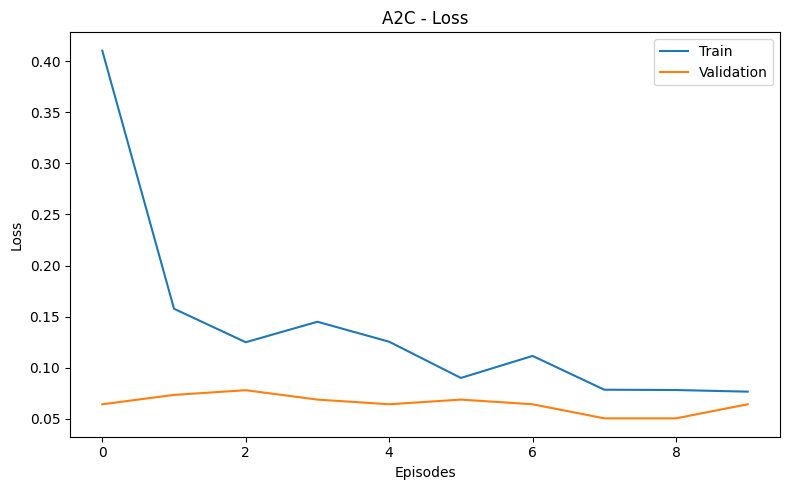

In [45]:
# Loss Curve
plt.figure(figsize=(8, 5))
plt.plot(train_loss_history, label='Train')
plt.plot(val_loss_history,   label='Validation')
plt.title('A2C - Loss')
plt.xlabel('Episodes')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

<h3>Confusion Matrix</h3>

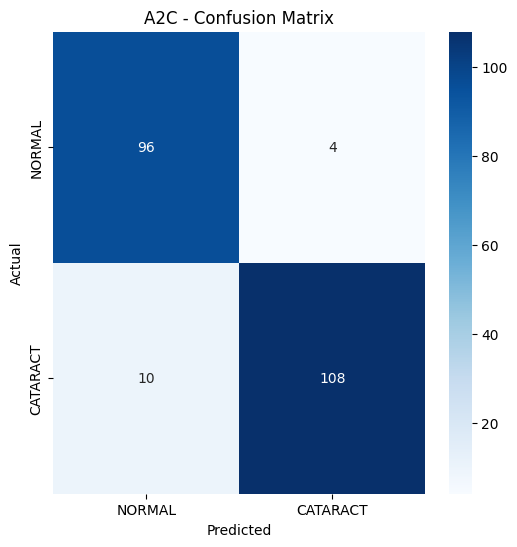

In [46]:
# Confusion Matrix (counts)
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL', 'CATARACT'],
            yticklabels=['NORMAL', 'CATARACT'])
plt.title('A2C - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Confusion Matrix — Counts & Normalized

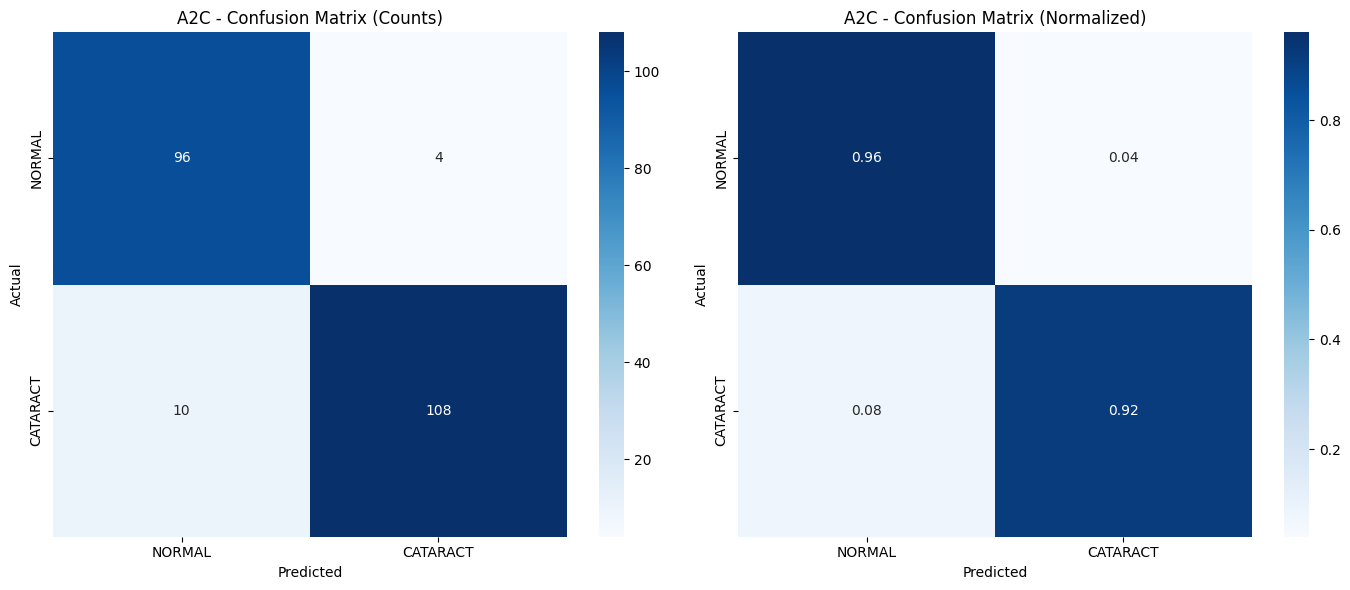

In [47]:
# Confusion Matrix - Counts & Normalized side by side
cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL','CATARACT'],
            yticklabels=['NORMAL','CATARACT'], ax=axes[0])
axes[0].set_title('A2C - Confusion Matrix (Counts)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=['NORMAL','CATARACT'],
            yticklabels=['NORMAL','CATARACT'], ax=axes[1])
axes[1].set_title('A2C - Confusion Matrix (Normalized)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [48]:
# Classification Report
from sklearn.metrics import classification_report
print('\nA2C - Classification Report:')
print(classification_report(y_true, y_pred, target_names=['NORMAL', 'CATARACT']))


A2C - Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.91      0.96      0.93       100
    CATARACT       0.96      0.92      0.94       118

    accuracy                           0.94       218
   macro avg       0.93      0.94      0.94       218
weighted avg       0.94      0.94      0.94       218



### ROC Curve

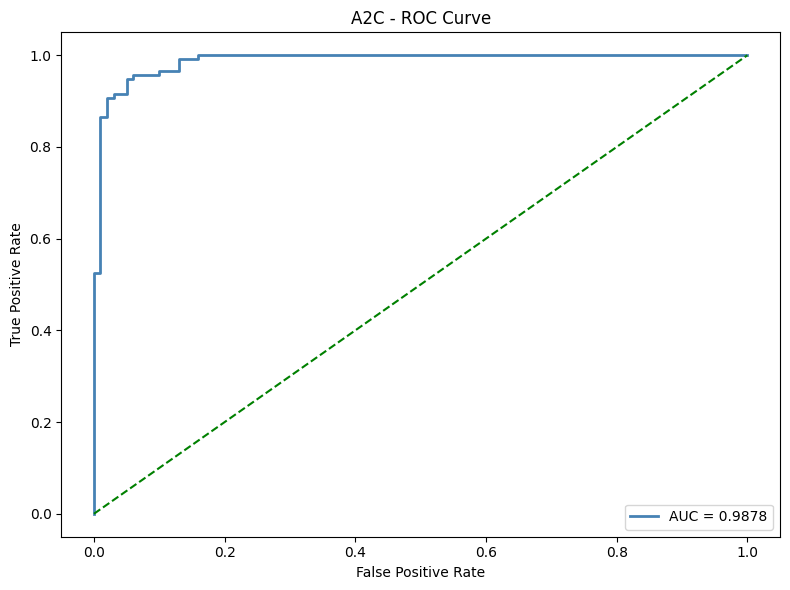

In [49]:
# ROC Curve
from sklearn.metrics import roc_curve, auc as sk_auc

fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc     = sk_auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], color='green', linestyle='--')
plt.title('A2C - ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Error Analysis

<Figure size 800x600 with 0 Axes>

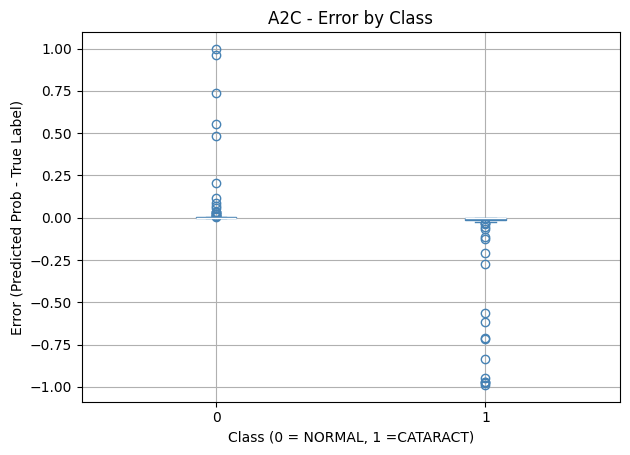

In [50]:
# Error by Class (box plot)
errors   = y_pred_prob - y_true
error_df = pd.DataFrame({'Error': errors, 'Class': y_true})

plt.figure(figsize=(8, 6))
error_df.boxplot(column='Error', by='Class', patch_artist=True,
                 boxprops=dict(facecolor='steelblue', color='steelblue'),
                 medianprops=dict(color='white'),
                 whiskerprops=dict(color='steelblue'),
                 capprops=dict(color='steelblue'),
                 flierprops=dict(markerfacecolor='none', markeredgecolor='steelblue'))
plt.title('A2C - Error by Class')
plt.suptitle('')
plt.xlabel('Class (0 = NORMAL, 1 =CATARACT)')
plt.ylabel('Error (Predicted Prob - True Label)')
plt.tight_layout()
plt.show()

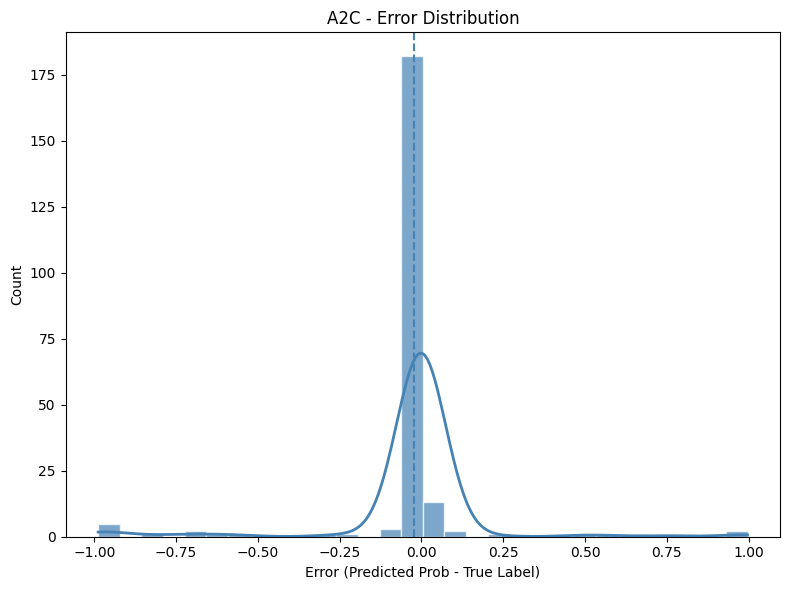

In [51]:
# Error Distribution
from scipy.stats import gaussian_kde

errors = y_pred_prob - y_true
plt.figure(figsize=(8, 6))
plt.hist(errors, bins=30, alpha=0.7, color='steelblue', edgecolor='white')
kde_x = np.linspace(errors.min(), errors.max(), 300)
kde_y = gaussian_kde(errors)(kde_x) * len(errors) * (errors.max() - errors.min()) / 30
plt.plot(kde_x, kde_y, color='steelblue', lw=2)
plt.axvline(errors.mean(), color='steelblue', linestyle='--')
plt.title('A2C - Error Distribution')
plt.xlabel('Error (Predicted Prob - True Label)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Prediction Probability & Scatter

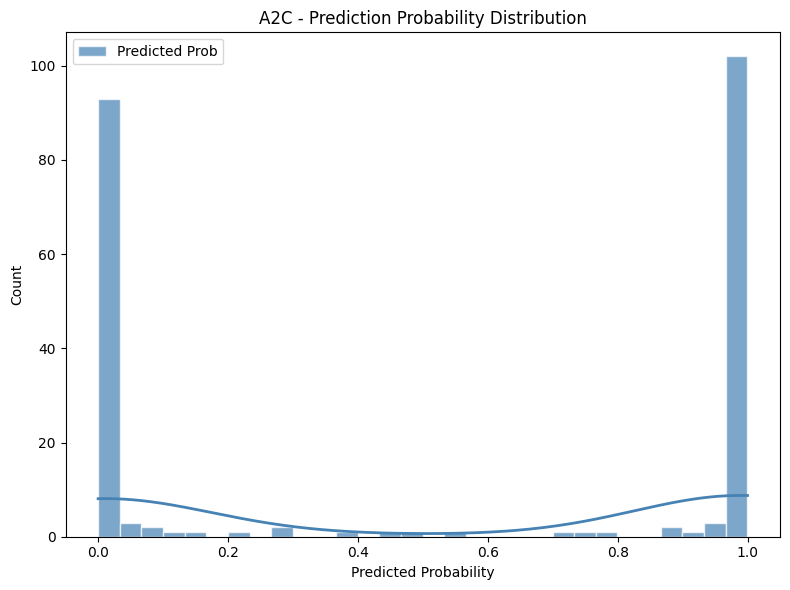

In [52]:
# Prediction Probability Distribution
from scipy.stats import gaussian_kde

probs = y_pred_prob
plt.figure(figsize=(8, 6))
plt.hist(probs, bins=30, alpha=0.7, color='steelblue', edgecolor='white', label='Predicted Prob')
kde_x = np.linspace(0, 1, 300)
kde_y = gaussian_kde(probs)(kde_x) * len(probs) * (1 / 30)
plt.plot(kde_x, kde_y, color='steelblue', lw=2)
plt.title('A2C - Prediction Probability Distribution')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

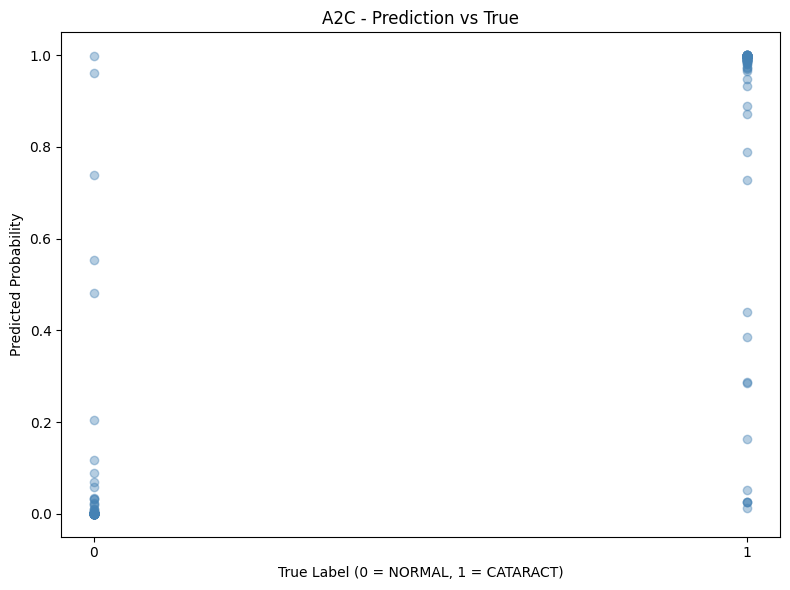

In [53]:
# Prediction vs True (scatter)
plt.figure(figsize=(8, 6))
plt.scatter(y_true, y_pred_prob, alpha=0.4, color='steelblue')
plt.title('A2C - Prediction vs True')
plt.xlabel('True Label (0 = NORMAL, 1 = CATARACT)')
plt.ylabel('Predicted Probability')
plt.xticks([0, 1])
plt.tight_layout()
plt.show()

<h3>Prediction: Actual vs Predicted</h3>

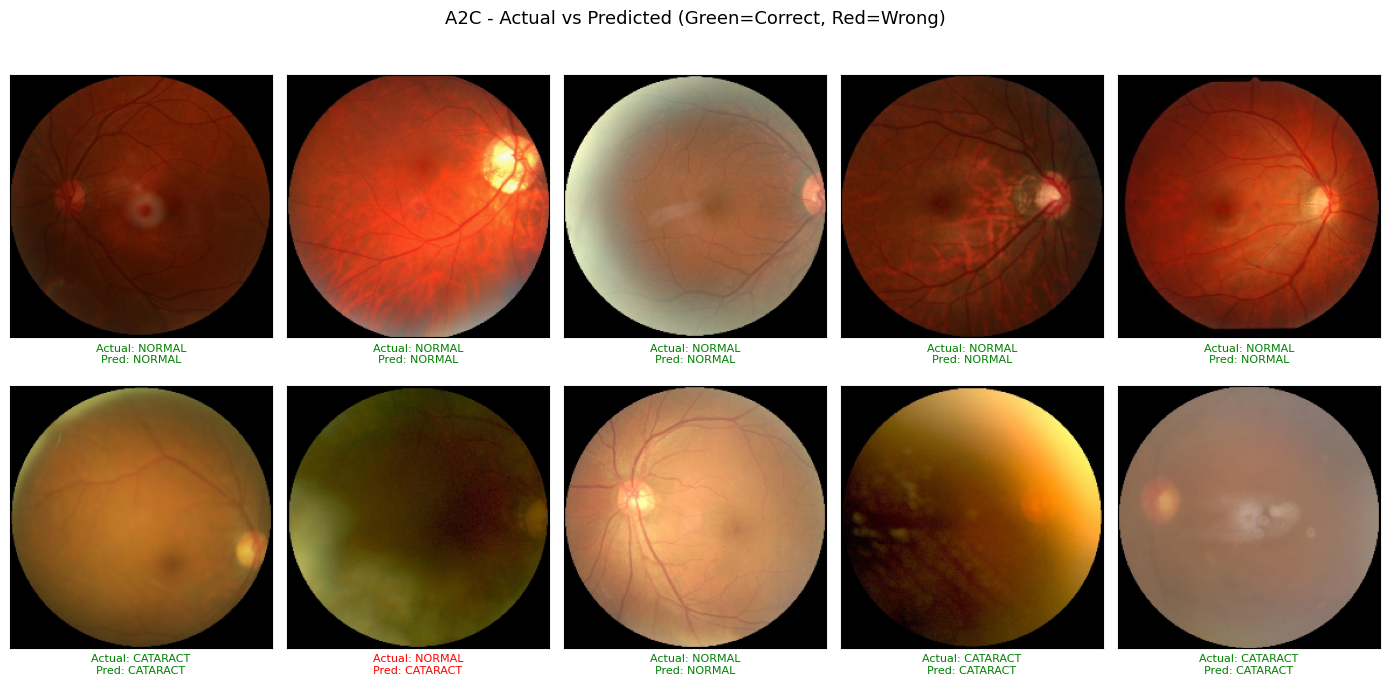

In [54]:
# Visualise predictions on validation images
val_paths = val_df['filename'].reset_index(drop=True).values
class_map = {0: 'NORMAL', 1: 'CATARACT'}

plt.figure(figsize=(14, 7))
indices = random.sample(range(len(val_paths)), 10)
for plot_i, idx in enumerate(indices):
    image = cv2.imread(val_paths[idx])
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (224, 224))

    actual    = class_map[y_true[idx]]
    predicted = class_map[y_pred[idx]]
    color     = 'green' if actual == predicted else 'red'

    plt.subplot(2, 5, plot_i + 1)
    plt.imshow(image)
    plt.xlabel(f'Actual: {actual}\nPred: {predicted}', color=color, fontsize=8)
    plt.xticks([]); plt.yticks([])

plt.suptitle('A2C - Actual vs Predicted (Green=Correct, Red=Wrong)', fontsize=13)
plt.tight_layout()
plt.show()